# PLANT LEAF DISEASE DETECTION


<img src="Images/dataset-cover.png" alt="Sample Image" width="600">


# 1. Business Understanding

## 1.1 Project Overview

Agriculture is a key pillar of food security and economic growth globally and particularly in developing countries where a large percentage of the population depends on farming for their livelihood. However, crop diseases remain one of the major threats to agricultural productivity, leading to reduced yields, financial losses, and food insecurity.

In this project, we focus on the detection of plant leaf diseases in corn, tomato and potato crops using image classification techniques. The goal is to build a machine learning model capable of identifying whether a plant leaf is healthy or diseased based on visual symptoms. By automating disease detection, farmers can take timely action to prevent disease spread, improve crop health, and reduce reliance on manual inspection, which is often slow, inaccurate, and requires expert knowledge.

## 1.2 Problem Statement

Crop diseases such as blight, leaf spots and rust significantly affect the productivity of corn, tomato and potato plants. Traditional disease detection relies heavily on manual observation by farmers or agricultural experts, which is both time-consuming and prone to human error. There is therefore a need for a technological solution that can accurately and efficiently detect and classify plant leaf diseases at an early stage. This will help farmers make informed decisions on disease management, reduce crop losses, and improve overall agricultural productivity.

## 1.3 Business Objectives

### 1.3.1 Main Objective

To develop an image classification model that can automatically detect and classify leaf diseases in corn, tomato, and potato plants.

### 1.3.2 Specific Objectives

- To collect and preprocess images of corn, tomato, and potato leaves (both healthy and diseased).

- To train and evaluate a machine learning model capable of identifying disease types based on leaf images.

- To compare model performance using different classification algorithms.

- To provide a simple, user-friendly interface that can assist farmers in identifying crop diseases through image uploads.

### 1.3.3 Research Questions

- What types of diseases affect corn, tomato, and potato leaves?

- Can image classification accurately identify diseased leaves?

- Which model gives the best results in detecting plant leaf diseases?

- How can the model’s results be presented in a way that is easy for farmers to understand?

## 1.4 Success Criteria

- The model achieves an accuracy of 90% or higher on test images.

- It correctly identifies and classifies diseases in all three crops.

- It has a low number of false results.

- A simple system or interface is developed for easy use by farmers.

# 2. Data Understanding

The dataset used in this project comes from [Mendeley Data — “PlantVillage Dataset: Potato Leaf Disease”](https://data.mendeley.com/datasets/tywbtsjrjv/1)

It contains labeled images of potato leaves under 10 categories

Data Summary:
- Total images: 25000 original images.
- Classes: 10
- Format: JPEG
- Resolution: Variable, to be resized to 224×224 for model training.
- Image collection: Captured under field and controlled lighting conditions.

## Loading Our Dataset

In [26]:
import tensorflow as tf
import os
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib
from PIL import Image
import cv2
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import load_img, img_to_array
import shutil


# Path to your dataset folder
dataset_path = "Plant disease dataset"

# Load dataset 
data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,   
    batch_size=32,
    shuffle=True
)

# Show all class names
print("Classes found:")
print(data.class_names)

Found 25000 files belonging to 10 classes.
Classes found:
['Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Corn___Common_rust', 'Corn___Northern_Leaf_Blight', 'Corn___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy_aug', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___healthy']


## Counting all Images in each class

In [27]:
# count of images from all our classes

dataset_path = "Plant disease dataset"

# Get class names 
classes = sorted(os.listdir(dataset_path))

# Count images in each class
print("Class Counts:\n")
for class_name in classes:
    class_dir = os.path.join(dataset_path, class_name)
    count = len(os.listdir(class_dir))
    print(f"{class_name}: {count} images")

Class Counts:

Corn___Cercospora_leaf_spot Gray_leaf_spot: 2500 images
Corn___Common_rust: 2500 images
Corn___Northern_Leaf_Blight: 2500 images
Corn___healthy: 2500 images
Potato___Early_blight: 2500 images
Potato___Late_blight: 2500 images
Potato___healthy_aug: 2500 images
Tomato___Early_blight: 2500 images
Tomato___Late_blight: 2500 images
Tomato___healthy: 2500 images


## Checking for duplicates

In [28]:
# To check and count duplicates

def count_duplicates(dataset):
    seen = set()
    duplicates = 0
    
    for images, _ in dataset:
        for img in images:
            img_hash = hashlib.md5(img.numpy().tobytes()).hexdigest()
            if img_hash in seen:
                duplicates += 1
            else:
                seen.add(img_hash)
    
    print(f"Unique images: {len(seen)}")
    print(f"Duplicate images: {duplicates}")

# Using the function
count_duplicates(data)


Unique images: 24986
Duplicate images: 14


## Checking for corrupt images

In [29]:
# Checking and counting corrupt images

corrupted_images = []

for c in classes:
    class_path = os.path.join(dataset_path, c)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()  
        except Exception as e:
            corrupted_images.append(img_path)

print(f"Total corrupted images found: {len(corrupted_images)}")

if corrupted_images:
    print("Some images are corrupted. Example:")
    print(corrupted_images[:5])
else:
    print("No corrupted images found.")

Total corrupted images found: 0
No corrupted images found.


# 3. EDA

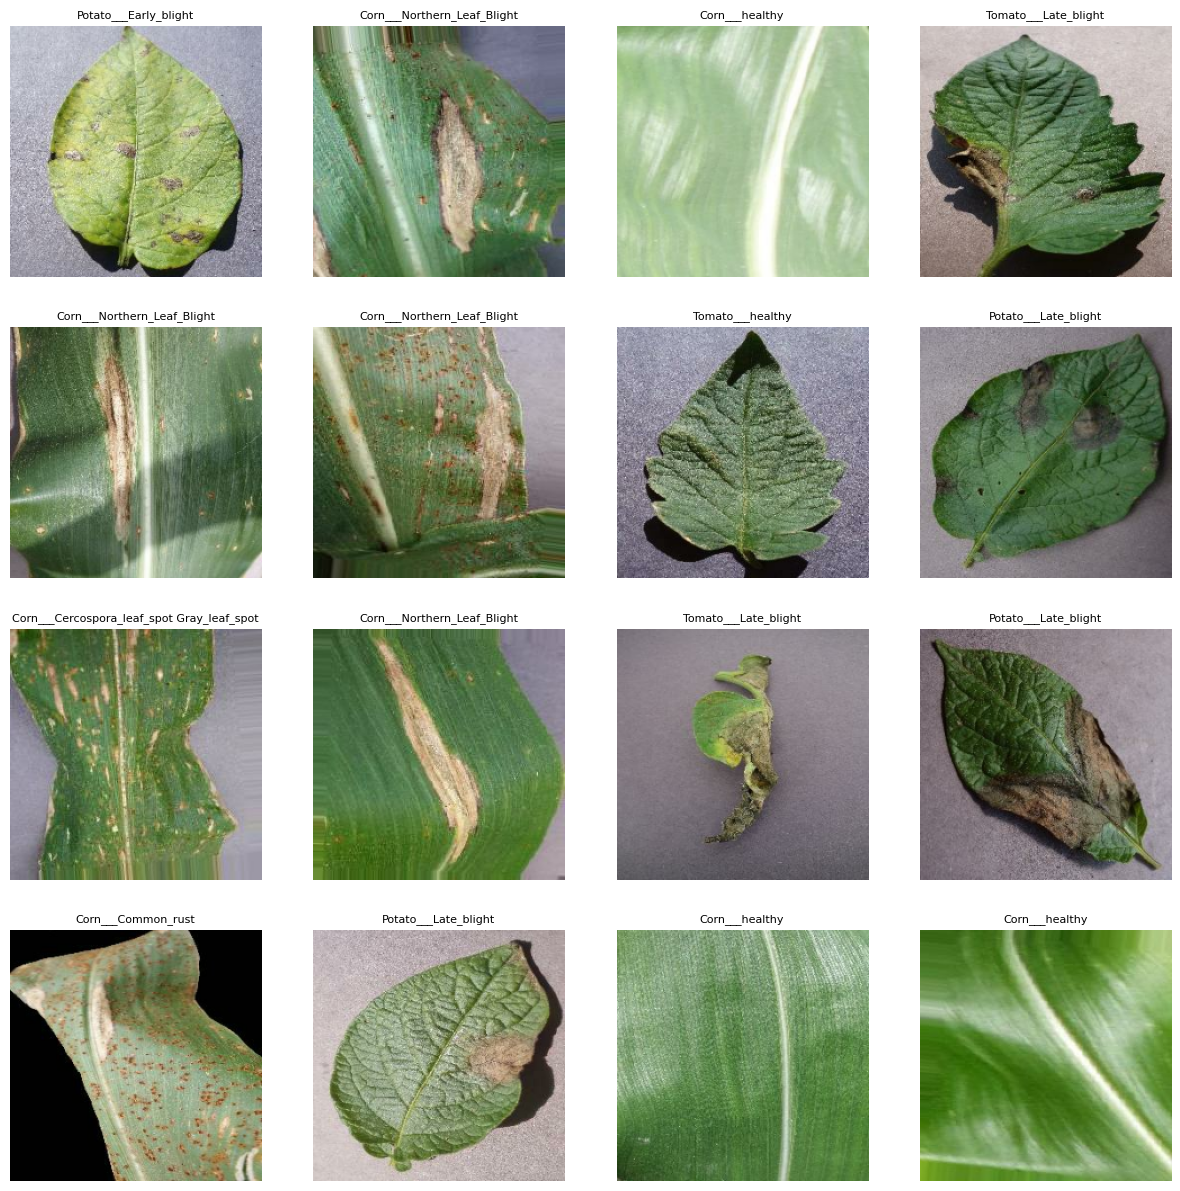

In [5]:
# Preview of random images from our classes 

plt.figure(figsize=(15, 15))
for images, labels in data.take(1):
    for i in range(16):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(data.class_names[labels[i]], fontsize=8)
        plt.axis("off")
plt.show()

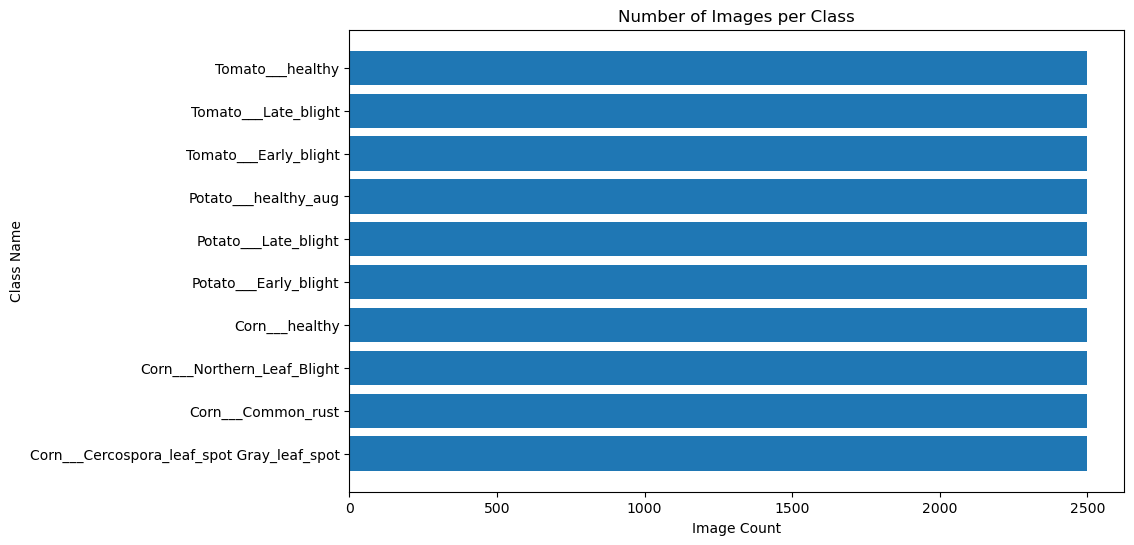

In [6]:
# count of the 10 classes
plt.figure(figsize=(10,6))
plt.barh(classes, [len(os.listdir(os.path.join(dataset_path, c))) for c in classes])
plt.title("Number of Images per Class")
plt.xlabel("Image Count")
plt.ylabel("Class Name")
plt.show()

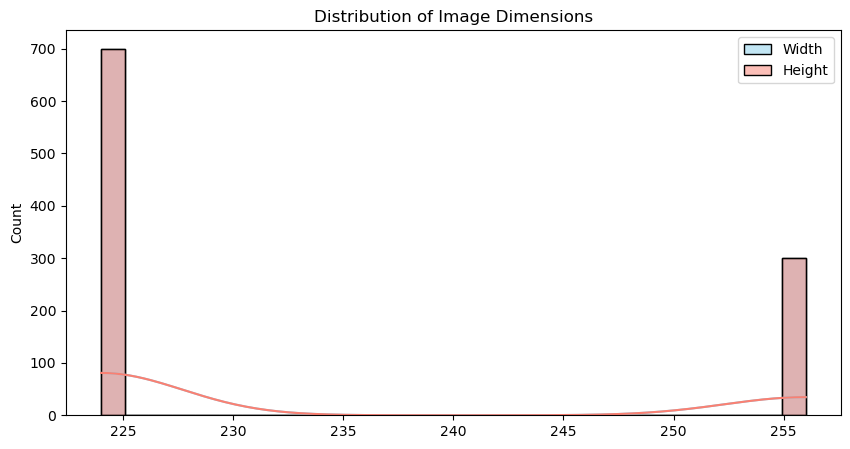

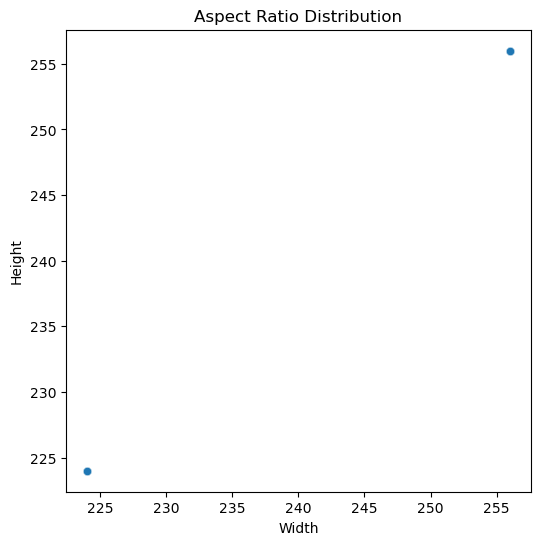

In [30]:
# Image Dimension and Aspect Ratio Distribution

widths, heights = [], []

for cls in classes:
    folder = os.path.join(dataset_path, cls)
    for img_name in os.listdir(folder)[:100]:  
        img_path = os.path.join(folder, img_name)
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)
        except:
            continue

# Plot width/height distribution
plt.figure(figsize=(10, 5))
sns.histplot(widths, bins=30, color='skyblue', kde=True, label='Width')
sns.histplot(heights, bins=30, color='salmon', kde=True, label='Height')
plt.legend()
plt.title("Distribution of Image Dimensions")
plt.show()

# Aspect ratio scatter plot
plt.figure(figsize=(6, 6))
sns.scatterplot(x=widths, y=heights, alpha=0.5)
plt.title("Aspect Ratio Distribution")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()


This indicates that most images in your dataset are either 224×224 or 256×256 pixels.

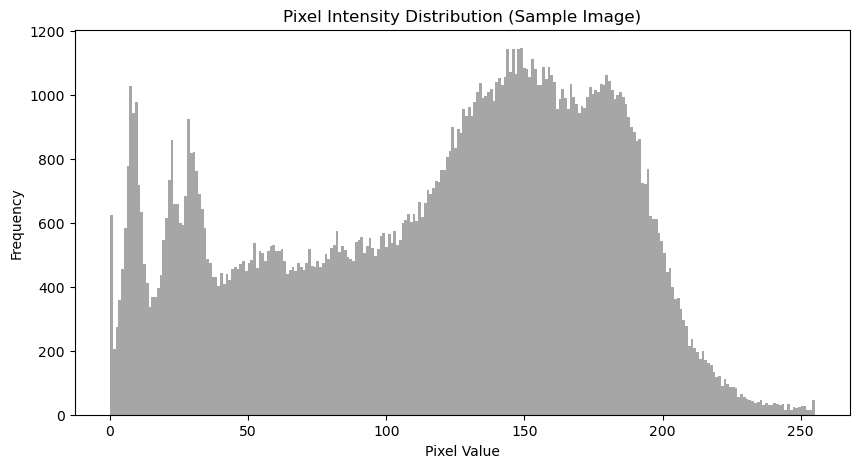

In [35]:
# Analyzing Pixel Intensity for a sample image

sample_path = os.path.join(dataset_path, classes[0], os.listdir(os.path.join(dataset_path, classes[0]))[0])
img = cv2.imread(sample_path)
plt.figure(figsize=(10, 5))
plt.hist(img.ravel(), bins=256, color='gray', alpha=0.7)
plt.title("Pixel Intensity Distribution (Sample Image)")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

The large hump in the middle means many pixels are mid-toned, neither too dark nor too bright.

# 4. Data Preparation

## Removing Duplicates

In [7]:
# Removing  duplicates
def remove_duplicates(dataset):
    seen = set()
    clean_images, clean_labels = [], []
    
    for images, labels in dataset:
        for i, img in enumerate(images):
            h = hashlib.md5(img.numpy().tobytes()).hexdigest()
            if h not in seen:
                seen.add(h)
                clean_images.append(img)
                clean_labels.append(labels[i])
    
    return tf.data.Dataset.from_tensor_slices(
        (tf.stack(clean_images), tf.stack(clean_labels))
    )

# Using the function
data = remove_duplicates(data)
print("Done")


Done


## Splitting the Data

In [44]:
# Training set
train_ds = tf.keras.utils.image_dataset_from_directory(
    "Plant disease dataset",
    validation_split=0.3,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32,
    color_mode='rgb'
)

# Validation set
val_test_ds = tf.keras.utils.image_dataset_from_directory(
    "Plant disease dataset",
    validation_split=0.3,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32,
    color_mode='rgb'
)

# Split 15% val and 15% test
val_batches = tf.data.experimental.cardinality(val_test_ds)
val_ds = val_test_ds.take(val_batches // 2)
test_ds = val_test_ds.skip(val_batches // 2)

Found 25000 files belonging to 10 classes.
Using 17500 files for training.
Found 25000 files belonging to 10 classes.
Using 7500 files for validation.


In [11]:
# Light augmentation
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [12]:
# class names
class_names = train_ds.class_names

# 4. Modeling

### Convolutional Neaural Network

In [13]:
# CNN model
model = Sequential([
    data_augmentation,
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


| Layer               | Purpose                                             |
| ------------------- | --------------------------------------------------- |
| `Conv2D(32)`        | Detects simple features (edges, textures)           |
| `MaxPooling2D()` | Reduces image size to focus on main features        |
| `Conv2D(64)`        | Learns more complex patterns (disease spots, veins) |
| `MaxPooling2D()` | Further compresses spatial information              |
| `Flatten()`         | Converts 2D feature maps into a 1D vector           |
| `Dense(128, relu)`  | Learns complex relationships                        |
| `Dropout(0.3)`      | Reduces overfitting                                 |
| `Dense(10, softmax)` | Outputs probabilities for each disease class        |

In [15]:
# Compiling the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
# Training the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40
)

Epoch 1/40
547/547 ━━━━━━━━━━━━━━━━━━━━ 499s 903ms/step - accuracy: 0.6389 - loss: 1.0109 - val_accuracy: 0.7997 - val_loss: 0.5169
Epoch 2/40
547/547 ━━━━━━━━━━━━━━━━━━━━ 982s 2s/step - accuracy: 0.8002 - loss: 0.5351 - val_accuracy: 0.8721 - val_loss: 0.3426
Epoch 3/40
547/547 ━━━━━━━━━━━━━━━━━━━━ 2572s 5s/step - accuracy: 0.8264 - loss: 0.4707 - val_accuracy: 0.8707 - val_loss: 0.3377
Epoch 4/40
547/547 ━━━━━━━━━━━━━━━━━━━━ 416s 761ms/step - accuracy: 0.8559 - loss: 0.3856 - val_accuracy: 0.8795 - val_loss: 0.3072
Epoch 5/40
547/547 ━━━━━━━━━━━━━━━━━━━━ 448s 818ms/step - accuracy: 0.8579 - loss: 0.3800 - val_accuracy: 0.9057 - val_loss: 0.2332
Epoch 6/40
547/547 ━━━━━━━━━━━━━━━━━━━━ 451s 826ms/step - accuracy: 0.8787 - loss: 0.3335 - val_accuracy: 0.9265 - val_loss: 0.1911
Epoch 7/40
547/547 ━━━━━━━━━━━━━━━━━━━━ 562s 1s/step - accuracy: 0.8865 - loss: 0.3041 - val_accuracy: 0.8878 - val_loss: 0.3700
Epoch 8/40
547/547 ━━━━━━━━━━━━━━━━━━━━ 696s 1s/step - accuracy: 0.8953 - loss: 0.27

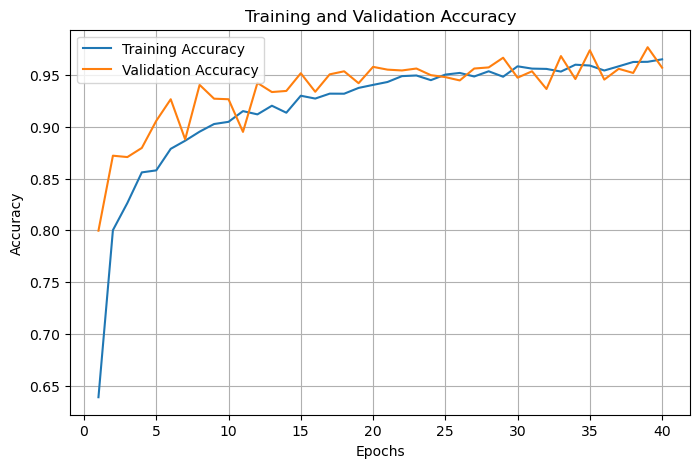

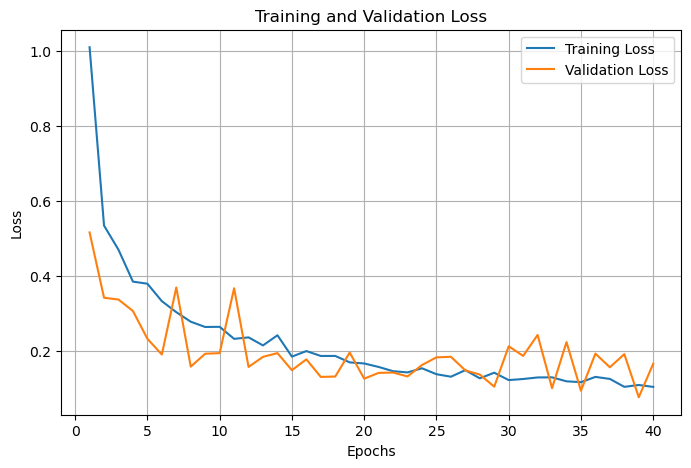

In [17]:
# Extract data from the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# Plot Training & Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot Training & Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

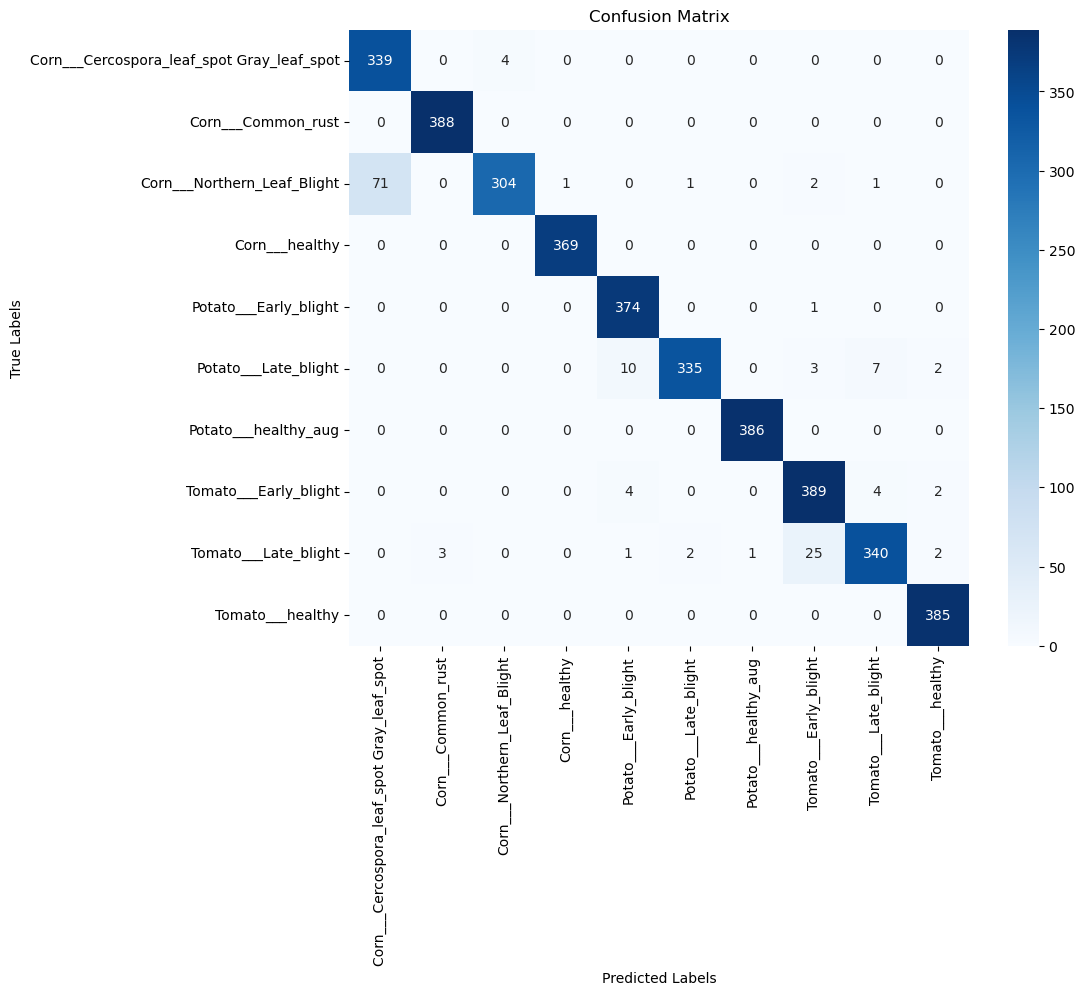

In [18]:
# Get class names from your dataset
class_names = train_ds.class_names

# Get model predictions on test set
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Generate classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

## Transfer Learning

### MobileNetV2

In [50]:
# MobileNetV2 model
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# Load pretrained model without the top classification layer
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze the base model so its weights don’t change during training
base_model.trainable = False

# Add your custom layers on top
model_2 = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')  
])

model_2.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [51]:
# Compiling our model
model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [52]:
# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model_2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop]
)


Epoch 1/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 303s 544ms/step - accuracy: 0.7717 - loss: 0.6192 - val_accuracy: 0.8627 - val_loss: 0.3586
Epoch 2/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 1282s 487ms/step - accuracy: 0.8491 - loss: 0.3856 - val_accuracy: 0.8806 - val_loss: 0.3069
Epoch 3/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 302s 551ms/step - accuracy: 0.8675 - loss: 0.3330 - val_accuracy: 0.8900 - val_loss: 0.2740
Epoch 4/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 319s 583ms/step - accuracy: 0.8798 - loss: 0.3002 - val_accuracy: 0.8953 - val_loss: 0.2717
Epoch 5/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 296s 541ms/step - accuracy: 0.8853 - loss: 0.2849 - val_accuracy: 0.9036 - val_loss: 0.2507
Epoch 6/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 9351s 17s/step - accuracy: 0.8923 - loss: 0.2644 - val_accuracy: 0.9065 - val_loss: 0.2541
Epoch 7/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 385s 704ms/step - accuracy: 0.8998 - loss: 0.2482 - val_accuracy: 0.8913 - val_loss: 0.2637
Epoch 8/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 511s 933ms/step - accuracy: 0.9042 -

In [54]:
# Get model predictions on test set
y_true_2 = []
y_pred_2 = []

for images, labels in test_ds:
    preds_2 = model_2.predict(images)
    y_true_2.extend(labels.numpy())
    y_pred_2.extend(np.argmax(preds_2, axis=1))

y_true_2 = np.array(y_true_2)
y_pred_2 = np.array(y_pred_2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 683ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 733ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 703ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 717ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 661ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 659ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 654ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 677ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 655ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 677ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 703ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 771ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 726ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 695ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 679ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 666ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

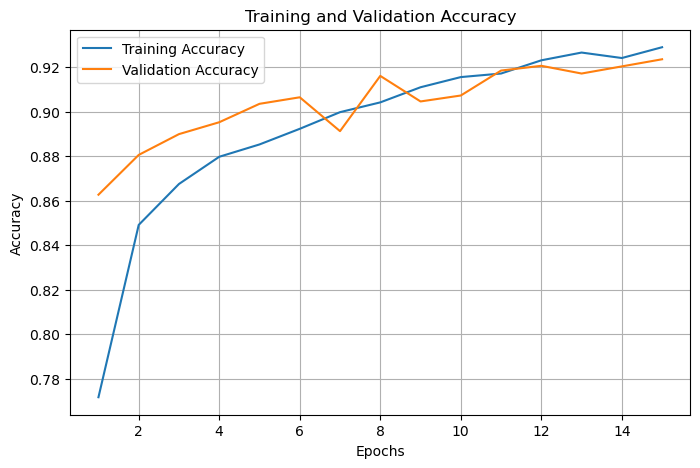

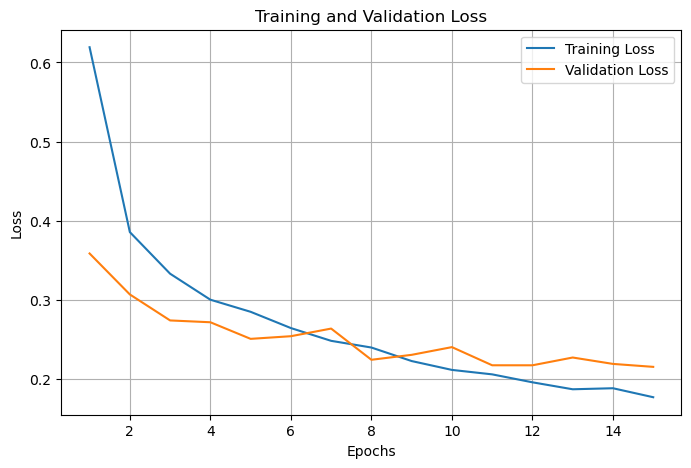

In [55]:
# Extract data from the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# Plot Training & Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot Training & Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


Classification Report:
                                            precision    recall  f1-score   support

Corn___Cercospora_leaf_spot Gray_leaf_spot       0.78      0.89      0.83       340
                        Corn___Common_rust       0.99      0.99      0.99       386
               Corn___Northern_Leaf_Blight       0.88      0.75      0.81       375
                            Corn___healthy       0.99      0.99      0.99       370
                     Potato___Early_blight       0.94      0.96      0.95       374
                      Potato___Late_blight       0.83      0.97      0.90       367
                      Potato___healthy_aug       1.00      1.00      1.00       382
                     Tomato___Early_blight       0.90      0.84      0.87       396
                      Tomato___Late_blight       0.90      0.79      0.84       378
                          Tomato___healthy       0.96      0.99      0.97       388

                                  accuracy        

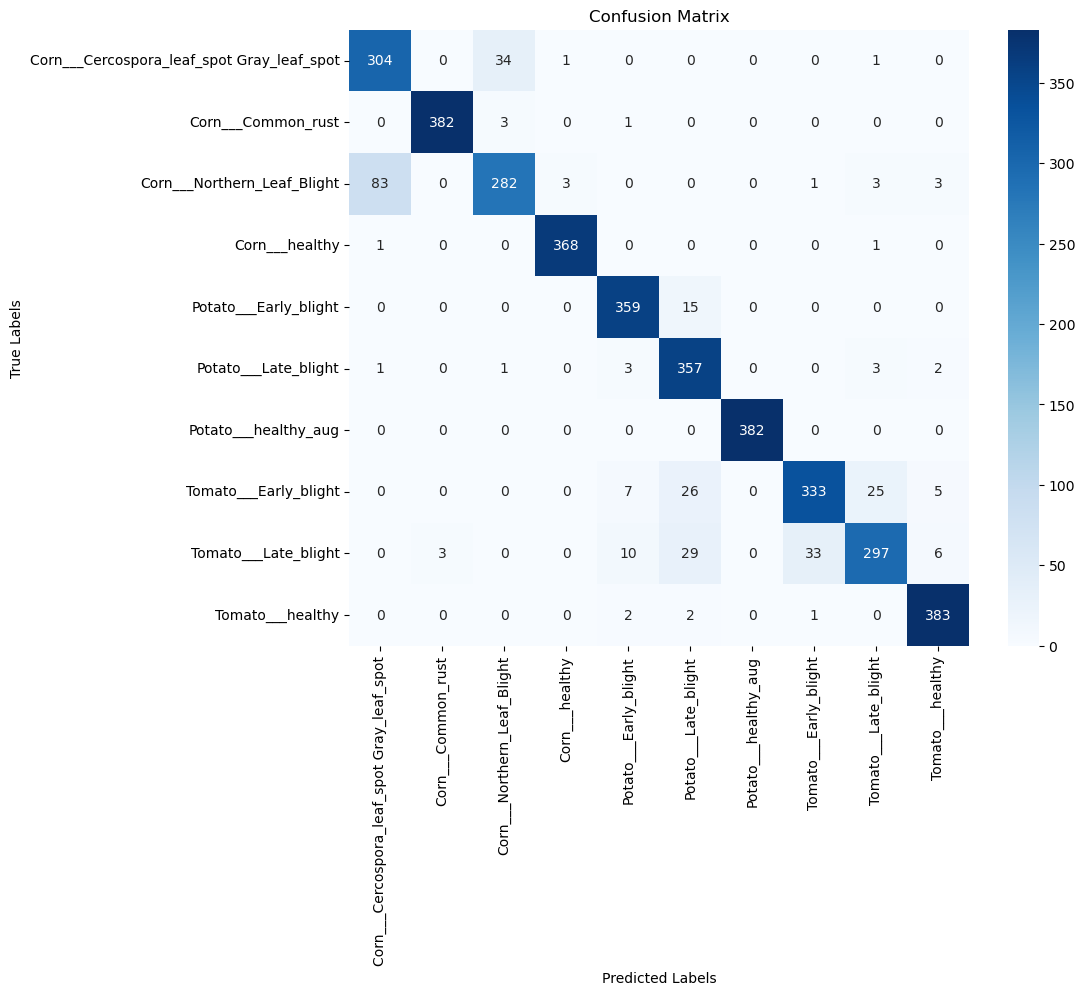

In [57]:
# Generate classification report
print("\nClassification Report:")
print(classification_report(y_true_2, y_pred_2, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true_2, y_pred_2)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')

plt.ylabel('True Labels')
plt.show()

In [56]:
# Evaluation
test_loss, test_acc = model_2.evaluate(test_ds)
print(f" Test Accuracy: {test_acc*100:.4f}%")
print(f"Test Loss: {test_loss:.4f}")

118/118 ━━━━━━━━━━━━━━━━━━━━ 75s 600ms/step - accuracy: 0.9167 - loss: 0.2275
 Test Accuracy: 91.6667%
Test Loss: 0.2275


# 5. Evaluation

In [62]:
# Generate classification report
print("\n CNN Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


# Generate classification report
print("\n MobileNetV2 Classification Report:")
print(classification_report(y_true_2, y_pred_2, target_names=class_names))




 CNN Classification Report:
                                            precision    recall  f1-score   support

Corn___Cercospora_leaf_spot Gray_leaf_spot       0.83      0.99      0.90       343
                        Corn___Common_rust       0.99      1.00      1.00       388
               Corn___Northern_Leaf_Blight       0.99      0.80      0.88       380
                            Corn___healthy       1.00      1.00      1.00       369
                     Potato___Early_blight       0.96      1.00      0.98       375
                      Potato___Late_blight       0.99      0.94      0.96       357
                      Potato___healthy_aug       1.00      1.00      1.00       386
                     Tomato___Early_blight       0.93      0.97      0.95       399
                      Tomato___Late_blight       0.97      0.91      0.94       374
                          Tomato___healthy       0.98      1.00      0.99       385

                                  accuracy   

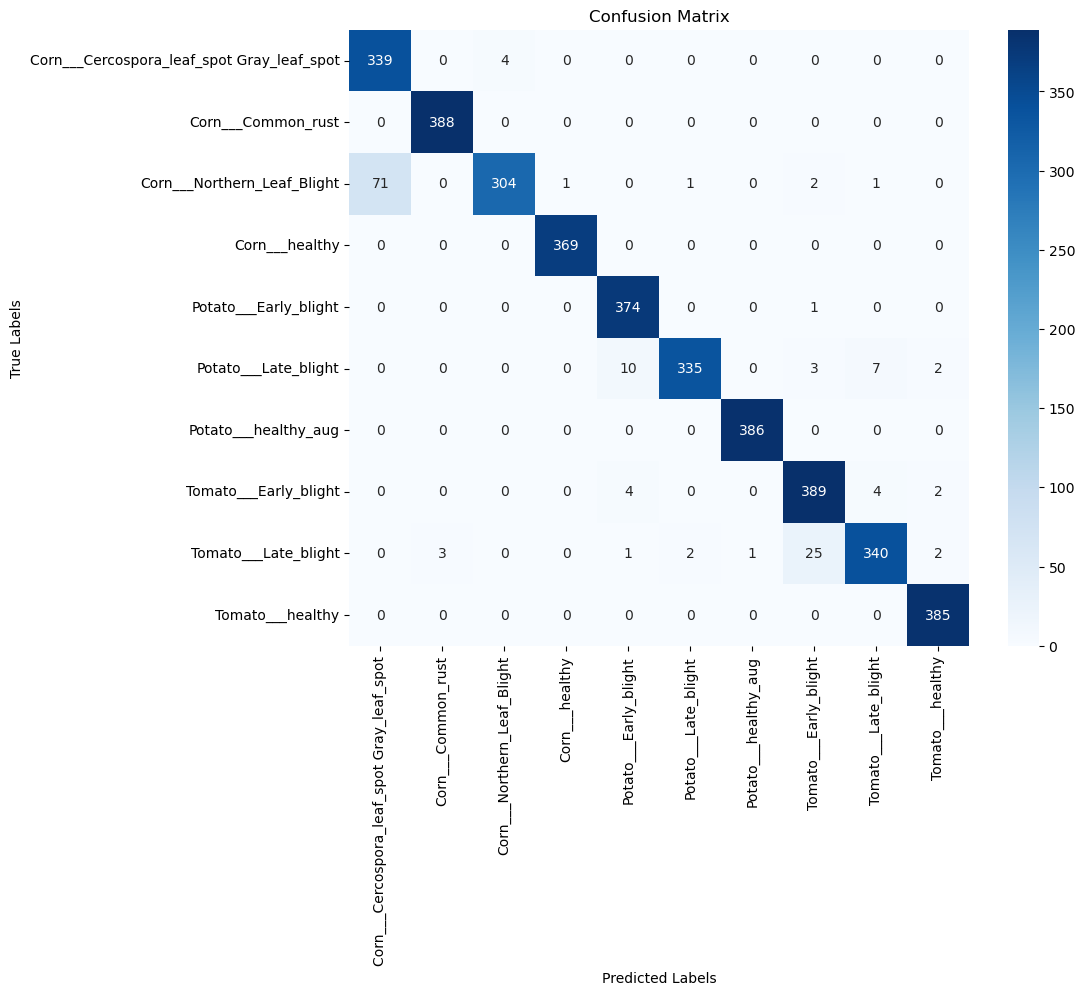

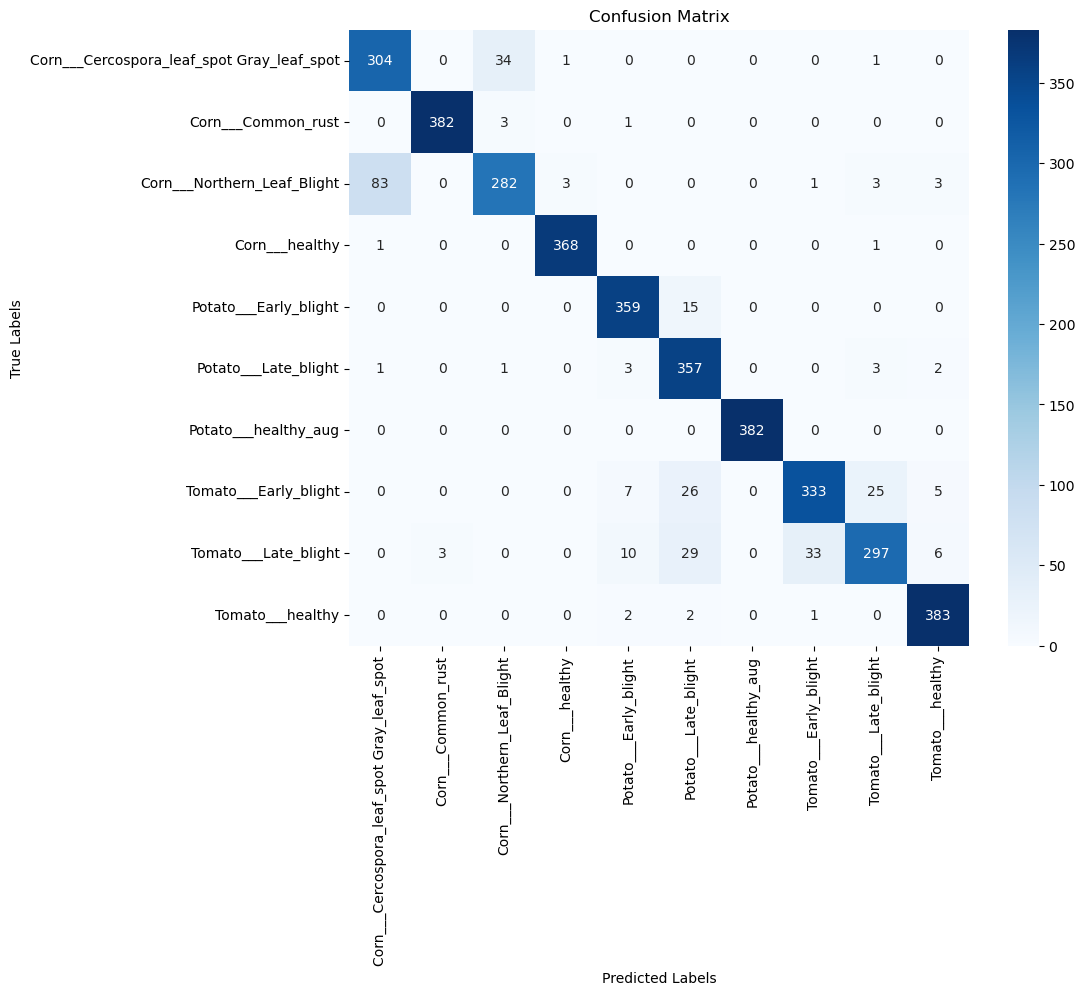

In [61]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


# Confusion matrix
cm_2 = confusion_matrix(y_true_2, y_pred_2)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


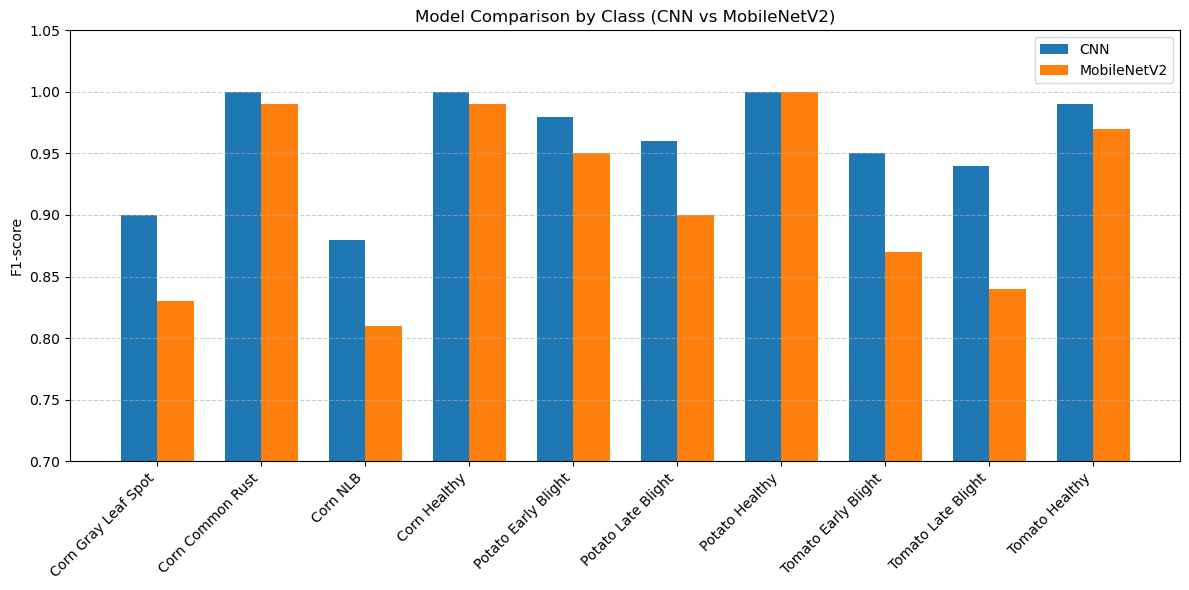

In [37]:
# F1-score comparison between the 2 models
# Class labels
classes = [
    "Corn Gray Leaf Spot", "Corn Common Rust", "Corn NLB", "Corn Healthy",
    "Potato Early Blight", "Potato Late Blight", "Potato Healthy",
    "Tomato Early Blight", "Tomato Late Blight", "Tomato Healthy"
]

# F1-scores
cnn_f1 = [0.90, 1.00, 0.88, 1.00, 0.98, 0.96, 1.00, 0.95, 0.94, 0.99]
mobilenet_f1 = [0.83, 0.99, 0.81, 0.99, 0.95, 0.90, 1.00, 0.87, 0.84, 0.97]

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, cnn_f1, width, label='CNN', color='#1f77b4')
plt.bar(x + width/2, mobilenet_f1, width, label='MobileNetV2', color='#ff7f0e')

plt.xticks(x, classes, rotation=45, ha='right')
plt.ylabel('F1-score')
plt.title('Model Comparison by Class (CNN vs MobileNetV2)')
plt.ylim(0.7, 1.05)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


CNN performs more consistently and slightly better across most classes.

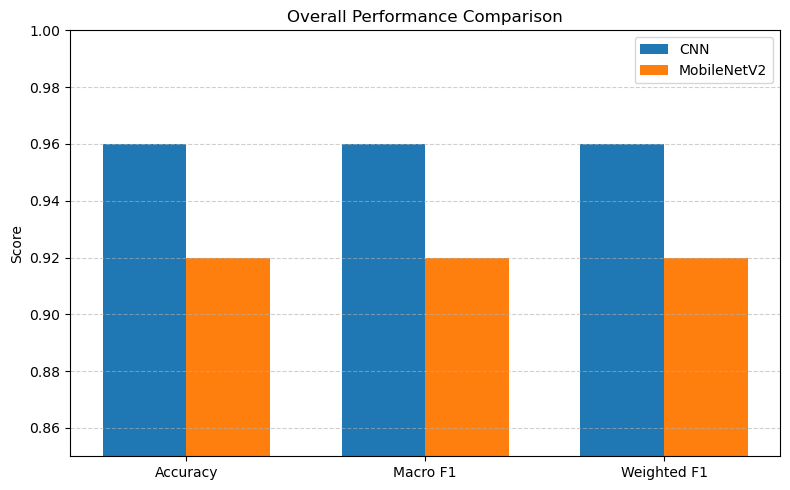

In [38]:
labels = ['Accuracy', 'Macro F1', 'Weighted F1']
cnn_scores = [0.96, 0.96, 0.96]
mobilenet_scores = [0.92, 0.92, 0.92]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, cnn_scores, width, label='CNN', color='#1f77b4')
plt.bar(x + width/2, mobilenet_scores, width, label='MobileNetV2', color='#ff7f0e')

plt.xticks(x, labels)
plt.ylabel('Score')
plt.title('Overall Performance Comparison')
plt.ylim(0.85, 1.0)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


CNN outperforms MobileNetV2 overall (0.96 vs 0.92).

In [59]:
# Manual testing
class_names = [
    'Corn___Cercospora_leaf_spot Gray_leaf_spot',
    'Corn___Common_rust',
    'Corn___Northern_Leaf_Blight',
    'Corn___healthy',
    'Potato___Early_blight',
    'Potato___Late_blight',
    'Potato___healthy_aug',
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Tomato___healthy'
]


def preprocess_image(image_path):
    img = load_img(image_path, target_size=(224, 224))  
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)       
    return img_array

test_dir = "New_Test_Images"  

for img_file in sorted(os.listdir(test_dir)):
    if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
        img_path = os.path.join(test_dir, img_file)
        img_array = preprocess_image(img_path)

        predictions = model_2.predict(img_array)
        score = tf.nn.softmax(predictions[0])
        pred_class = class_names[np.argmax(score)]
        confidence = 100 * np.max(score)

        print(f"Image: {img_file}")
        print(f"Predicted class: {pred_class} ({confidence:.2f}%)\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
Image: Northern-COrn-Leaf-Blight-Photo-The-Ohio-State-University.jpg
Predicted class: Corn___Northern_Leaf_Blight (15.94%)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
Image: aug_0_4.jpg
Predicted class: Potato___healthy_aug (23.20%)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
Image: nlb.JPG
Predicted class: Corn___Cercospora_leaf_spot Gray_leaf_spot (18.18%)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
Image: nlb_2.jpeg
Predicted class: Corn___Northern_Leaf_Blight (15.95%)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
Image: plb.jpg
Predicted class: Potato___Late_blight (23.19%)



In [48]:
# Saving the model
model.save("model.keras")

In [49]:
# Compressing the file
shutil.make_archive("plant_disease_model", 'zip', ".", "model.keras")


'C:\\Users\\user\\plant_disease_model.zip'

# Conclusion

In this project, two models a custom Convolutional Neural Network (CNN) and a MobileNetV2 transfer learning model were trained and evaluated on a plant disease dataset containing 10 distinct crop disease classes.
Each class had a balanced number of images (2,500), ensuring fair representation across categories.

| Model        | Accuracy | Macro F1 | Key Strengths                                                                 |
|---------------|-----------|----------|-------------------------------------------------------------------------------|
| **CNN**       | **0.96**  | **0.96** | Strong generalization, high recall and precision across all classes           |
| **MobileNetV2** | **0.92**  | **0.92** | Lightweight and efficient, but slightly lower recall for some disease classes |


The CNN outperformed MobileNetV2 in both accuracy and F1-score, indicating that the custom architecture was able to learn more robust features specific to this dataset.
All models achieved near-perfect performance on healthy leaf classes, with most errors occurring in visually similar disease types (e.g. Corn Northern Leaf Blight vs Cercospora Leaf Spot).

# Recommendations

### Model Choice 
The CNN model should be selected for deployment since it achieves the highest accuracy (96%) and balanced precision-recall performance.

### Practical Application
Deploy the CNN model via Streamlit for farmers or agronomists to upload leaf images and receive:
- The predicted disease class.
- Recommendations on treatment or management.

### Future Work
- Extend the dataset to include more plant species and real-world images which include varied lighting and backgrounds.
- Implement Grad-CAM visualizations to highlight which leaf areas the model focuses on.
- Consider edge deployment (e.g., TensorFlow Lite) for use in mobile devices.